
  ♔ CHESS BATTLE — Your Digital Army vs The Market

♟ Potential pawns: 2224

Loading processed data from cache...
♞ Loading Nifty for Knight hedge signals...
♞ Nifty loaded

♔ King's treasury    : ₹100,000
♔ Cash bodyguard     : 20% always reserved
♔ Total stop         : 10% portfolio drop → all retreat
♜ Max positions      : 5 (top 3 get 50% of capital)
♟ Pawn promotion     : at +50% gain
♞ Knight hedge       : deploys if Nifty drops >5.0% in a day

🏟 Battle starts over 2471 trading days...

  Turn 500/2471  |  Pawns: 5  |  Promoted: 1  |  Hedge: OFF  |  Treasury: ₹178,355
  Turn 1000/2471  |  Pawns: 7  |  Promoted: 1  |  Hedge: OFF  |  Treasury: ₹179,043
  Turn 1500/2471  |  Pawns: 7  |  Promoted: 0  |  Hedge: OFF  |  Treasury: ₹359,498
  Turn 2000/2471  |  Pawns: 7  |  Promoted: 0  |  Hedge: OFF  |  Treasury: ₹519,306

  ♔ CHESS BATTLE — FINAL RESULTS
  Period          : 2016-05-05 → 2026-05-05
  ♔ Starting      : ₹100,000
  ♔ Final         : ₹600,352
  Total Return    : 500.4%
  C

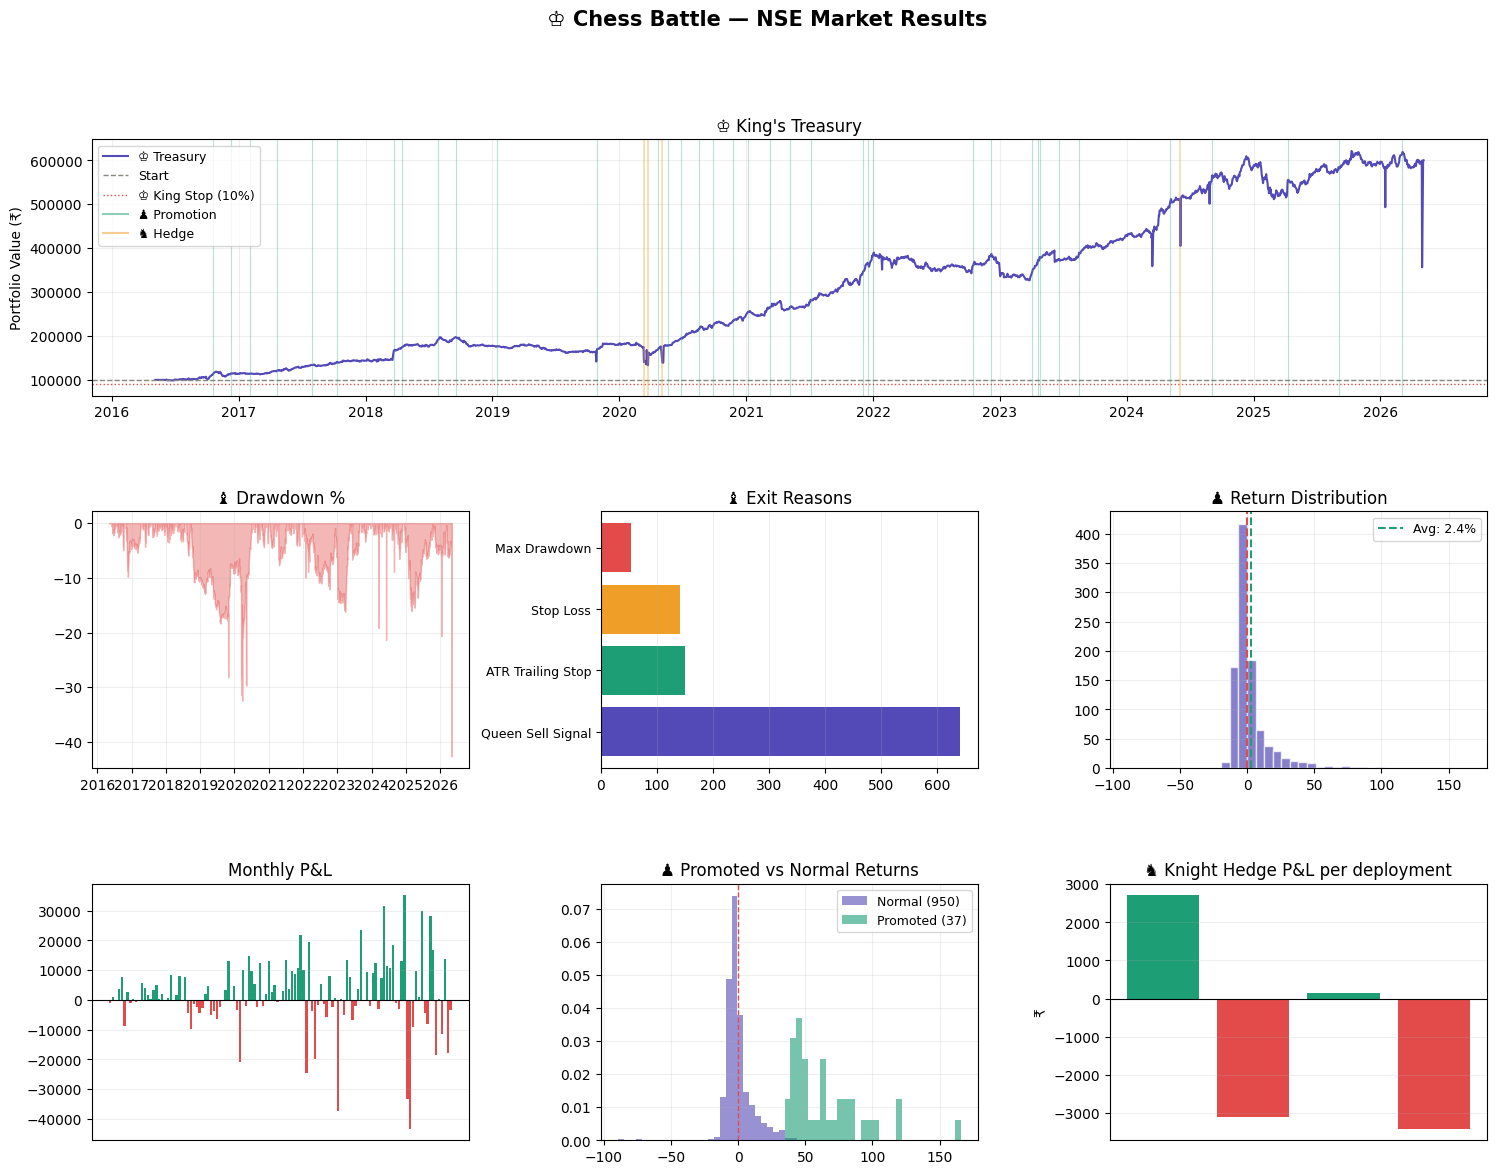

In [6]:
"""
=============================================================
  ♔ CHESS BATTLE — Real World Chess vs The Market
  ─────────────────────────────────────────────────────────

  PIECES & THEIR ROLES:
  ─────────────────────────────────────────────────────────
  ♔ KING   — Capital protection
               • Never lets total portfolio drop >20%
               • Keeps 25% cash as bodyguard at all times
               • If King is threatened → all pieces retreat

  ♛ QUEEN  — UTBot momentum attacker
               • Scans all 2000 NSE stocks every day
               • Only attacks the strongest signals
               • Ranks by momentum quality (low volatility + strong trend)

  ♝ BISHOP (White) — Long position guardian
               • Tight ATR trailing stop (locks in gains)
               • Hard stop loss 5% below entry (cuts losses fast)
               • Max drawdown 8% from peak

  ♝ BISHOP (Black) — Short/hedge position guardian
               • Covers the Knight's hedge positions
               • Exits hedge when market recovers (UTBot buy signal on Nifty)

  ♞ KNIGHTS — Hedge bots (inverse market positions)
               • When Nifty drops >1.5% in a day → Knights deploy hedge
               • Short NIFTY50 (or buy inverse ETF: NIFTYBEES short)
               • Protects King during market crashes
               • Exit when Nifty recovers above 5-day average

  ♜ ROOKS  — Capital concentrators
               • Max 8 positions (fewer, bigger bets)
               • Allocates 70% of deployable cash to top 3 signals
               • Remaining 30% spread across next 5 signals

  ♟ PAWNS  — Individual stock positions
               • When pawn gains 50%+ → PROMOTE
               • Promotion = sell 50% of position, lock profit
               • Let remaining 50% ride with trailing stop
               • Tracks promoted pawns separately

  ─────────────────────────────────────────────────────────
  OVERALL PHILOSOPHY:
    Few positions, high conviction, tight stops, let winners run
    Hedge during crashes, attack during bull runs
    King (capital) never fights directly — always protected
=============================================================
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pickle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ═══════════════════════════════════════════════
#  ♔ KING SETTINGS — Capital Protection
# ═══════════════════════════════════════════════
INITIAL_CAPITAL          = 100_000
KING_CASH_GUARD_PCT      = 0.20    # always keep 25% cash as King's bodyguard
KING_TOTAL_STOP_PCT      = 0.10    # if portfolio drops 20% → all pieces retreat
LOOKBACK_PERIOD          = "10y"

# ═══════════════════════════════════════════════
#  ♜ ROOK SETTINGS — Position Sizing
# ═══════════════════════════════════════════════
MAX_POSITIONS            = 5       # fewer, bigger bets
TOP_POSITIONS            = 3       # top 3 get 70% of deployable cash
TOP_ALLOCATION_PCT       = 0.50    # 70% to top 3 signals
REST_ALLOCATION_PCT      = 0.50    # 30% to next 5 signals

# ═══════════════════════════════════════════════
#  ♝ BISHOP SETTINGS — Defence
# ═══════════════════════════════════════════════
STOP_LOSS_PCT            = 0.08    # Bishop 1: cut loss at 5%
ATR_STOP_MULT            = 3.0     # Bishop 2: tight ATR trailing stop
MAX_DRAWDOWN_PCT         = 0.12    # Bishop 3: max 8% drawdown from peak

# ═══════════════════════════════════════════════
#  ♟ PAWN PROMOTION SETTINGS
# ═══════════════════════════════════════════════
PROMOTION_THRESHOLD      = 0.50    # pawn gains 50% → promote
PROMOTION_SELL_PCT       = 0.50    # sell 50% of position on promotion

# ═══════════════════════════════════════════════
#  ♞ KNIGHT SETTINGS — Hedge Bot
# ═══════════════════════════════════════════════
NIFTY_TICKER             = "^NSEI"
NIFTY_DROP_TRIGGER       = -0.05  # Knight deploys if Nifty drops >1.5%/day
HEDGE_ALLOCATION_PCT     = 0.2    # deploy 15% of portfolio as hedge
HEDGE_RECOVERY_DAYS      = 100       # exit hedge if Nifty above 5-day avg

# ═══════════════════════════════════════════════
#  ♛ QUEEN SETTINGS — UTBot
# ═══════════════════════════════════════════════
ATR_PERIOD               = 34

# CACHE
CACHE_FILE               = "price_cache.pkl"
PROCESSED_CACHE          = "processed_chess_battle.pkl"
USE_CACHE                = True
MAX_WORKERS              = 30

# ─────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────
def normalize_index(df):
    idx = df.index
    if hasattr(idx, "tz") and idx.tz is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    df.index = idx.normalize()
    return df

def load_nse_tickers():
    df      = pd.read_csv("data/EQUITY_L.csv")
    symbols = df["SYMBOL"].dropna().astype(str).str.strip().unique().tolist()
    return [s + ".NS" for s in symbols if "&" not in s]

# ─────────────────────────────────────────────
#  ♛ QUEEN — UTBot signal engine
# ─────────────────────────────────────────────
def compute_utbot(df):
    df    = df.copy()
    close = df["Close"]
    high  = df["High"]
    low   = df["Low"]

    tr = np.maximum(
        high - low,
        np.maximum(
            (high - close.shift()).abs(),
            (low  - close.shift()).abs()
        )
    )

    df["atr"]        = tr.rolling(ATR_PERIOD).mean()
    df["upper"]      = close - df["atr"]
    df["lower"]      = close + df["atr"]

    # Trend strength: distance from price to band (Queen's confidence)
    trend = [1]
    for i in range(1, len(df)):
        if   close.iloc[i] > df["lower"].iloc[i-1]: trend.append(1)
        elif close.iloc[i] < df["upper"].iloc[i-1]: trend.append(-1)
        else:                                        trend.append(trend[-1])

    df["trend"]          = trend
    df["buy"]            = (df["trend"] == 1)  & (df["trend"].shift() == -1)
    df["sell"]           = (df["trend"] == -1) & (df["trend"].shift() == 1)
    df["volatility"]     = close.pct_change(fill_method=None).rolling(20).std()

    # Momentum score: how strong is the trend (Queen's attack power)
    df["momentum"]       = close.pct_change(fill_method=None).rolling(10).mean()
    df["trend_strength"] = (close - close.rolling(20).mean()) / close.rolling(20).std()

    return df

# ─────────────────────────────────────────────
#  LOAD DATA
# ─────────────────────────────────────────────
def load_all_data(tickers):
    if USE_CACHE and os.path.exists(PROCESSED_CACHE):
        print("Loading processed data from cache...")
        with open(PROCESSED_CACHE, "rb") as f:
            return pickle.load(f)

    if USE_CACHE and os.path.exists(CACHE_FILE):
        print("Loading raw price cache...")
        price_data = pd.read_pickle(CACHE_FILE)
    else:
        print(f"Downloading {len(tickers)} stocks...")
        t0         = time.time()
        price_data = yf.download(
            tickers, period=LOOKBACK_PERIOD,
            group_by="ticker", auto_adjust=True,
            threads=True, progress=True
        )
        price_data.to_pickle(CACHE_FILE)
        print(f"Downloaded in {(time.time()-t0)/60:.1f} min")

    print("♛ Queen computing signals on all stocks...")
    all_data = {}

    def process(ticker):
        try:
            df = price_data[ticker].dropna()
            if df.empty or len(df) < 60: return None
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df = compute_utbot(df)
            df = normalize_index(df)
            return ticker, df
        except: return None

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        for r in ex.map(process, tickers):
            if r: all_data[r[0]] = r[1]

    print(f"♛ Queen marked {len(all_data)} stocks\n")
    with open(PROCESSED_CACHE, "wb") as f:
        pickle.dump(all_data, f)
    return all_data

def load_nifty():
    print("♞ Loading Nifty for Knight hedge signals...")
    try:
        nifty = yf.download(NIFTY_TICKER, period=LOOKBACK_PERIOD,
                            auto_adjust=True, progress=False)
        if isinstance(nifty.columns, pd.MultiIndex):
            nifty.columns = nifty.columns.get_level_values(0)
        nifty = normalize_index(nifty)
        nifty["daily_return"] = nifty["Close"].pct_change(fill_method=None)
        nifty["ma5"]          = nifty["Close"].rolling(5).mean()
        nifty["ma20"]         = nifty["Close"].rolling(20).mean()
        print("♞ Nifty loaded\n")
        return nifty
    except Exception as e:
        print(f"♞ Nifty load failed: {e}")
        return None

# ─────────────────────────────────────────────
#  ♜ ROOK — position sizer
#  Concentrates capital: top 3 get 70%, rest get 30%
# ─────────────────────────────────────────────
def rook_allocate(candidates, deployable_cash, open_count):
    """
    Rook's capital concentration strategy:
    Top 3 signals → share of 70% of deployable cash
    Next 5 signals → share of 30% of deployable cash
    Returns list of (ticker, row, allocation)
    """
    allocations = []
    n           = len(candidates)
    if n == 0 or deployable_cash <= 0:
        return allocations

    top    = candidates[:TOP_POSITIONS]
    rest   = candidates[TOP_POSITIONS:MAX_POSITIONS - open_count]

    if top:
        top_per  = (deployable_cash * TOP_ALLOCATION_PCT) / len(top)
        for ticker, score, row in top:
            allocations.append((ticker, row, top_per))

    if rest:
        rest_per = (deployable_cash * REST_ALLOCATION_PCT) / len(rest)
        for ticker, score, row in rest:
            allocations.append((ticker, row, rest_per))

    return allocations

# ─────────────────────────────────────────────
#  THE BATTLE (main backtest loop)
# ─────────────────────────────────────────────
def play_chess_battle(all_data, nifty):
    cash               = float(INITIAL_CAPITAL)
    open_positions     = {}       # ♟ pawns on the board
    promoted_pawns     = set()    # ♟→♛ pawns that got promoted
    hedge_active       = False    # ♞ Knight hedge deployed?
    hedge_entry        = None     # price at which hedge was entered
    trade_log          = []
    promotion_log      = []
    hedge_log          = []
    equity_curve       = []
    date_index         = []
    king_retreated     = False    # ♔ total stop triggered?

    # Normalize
    for t in list(all_data.keys()):
        all_data[t] = normalize_index(all_data[t])

    all_dates = sorted(set(
        d for df in all_data.values() for d in df.index
    ))

    print(f"♔ King's treasury    : ₹{INITIAL_CAPITAL:,.0f}")
    print(f"♔ Cash bodyguard     : {KING_CASH_GUARD_PCT*100:.0f}% always reserved")
    print(f"♔ Total stop         : {KING_TOTAL_STOP_PCT*100:.0f}% portfolio drop → all retreat")
    print(f"♜ Max positions      : {MAX_POSITIONS} (top {TOP_POSITIONS} get {TOP_ALLOCATION_PCT*100:.0f}% of capital)")
    print(f"♟ Pawn promotion     : at +{PROMOTION_THRESHOLD*100:.0f}% gain")
    print(f"♞ Knight hedge       : deploys if Nifty drops >{abs(NIFTY_DROP_TRIGGER)*100:.1f}% in a day")
    print(f"\n🏟 Battle starts over {len(all_dates)} trading days...\n")

    for turn, current_date in enumerate(all_dates):

        # ── ♔ KING CHECK: is the King safe? ───────────────
        # Compute total portfolio value
        total_pv = cash
        for t, pos in open_positions.items():
            df = all_data[t]
            if current_date in df.index:
                total_pv += pos["shares"] * float(df.loc[current_date]["Close"])

        # King's total stop — if portfolio fell 20%, all pieces retreat
        if not king_retreated:
            king_loss = (INITIAL_CAPITAL - total_pv) / INITIAL_CAPITAL
            if king_loss >= KING_TOTAL_STOP_PCT:
                print(f"\n♔ KING THREATENED on {current_date.date()}! "
                      f"Portfolio down {king_loss*100:.1f}%. ALL PIECES RETREAT.\n")
                king_retreated = True

        if king_retreated:
            # Liquidate everything — protect the King
            for ticker in list(open_positions.keys()):
                df = all_data[ticker]
                if current_date in df.index:
                    price    = float(df.loc[current_date]["Close"])
                    pos      = open_positions[ticker]
                    proceeds = pos["shares"] * price
                    profit   = proceeds - pos["invested"]
                    cash    += proceeds
                    trade_log.append({
                        "Stock":       ticker,
                        "Type":        "LONG",
                        "Entry Date":  pos["entry_date"],
                        "Exit Date":   current_date,
                        "Entry Price": round(pos["entry_price"], 2),
                        "Exit Price":  round(price, 2),
                        "Invested ₹":  round(pos["invested"], 2),
                        "Profit ₹":    round(profit, 2),
                        "Return %":    round((price/pos["entry_price"]-1)*100, 2),
                        "Holding Days":(current_date-pos["entry_date"]).days,
                        "Exit Reason": "♔ King Retreat (Total Stop)",
                        "Promoted":    ticker in promoted_pawns,
                    })
            open_positions.clear()
            equity_curve.append(cash)
            date_index.append(current_date)
            continue

        # ── ♞ KNIGHT: check hedge signal (Nifty) ──────────
        nifty_ret     = None
        nifty_close   = None
        nifty_ma5     = None

        if nifty is not None and current_date in nifty.index:
            nifty_row   = nifty.loc[current_date]
            nifty_ret   = float(nifty_row["daily_return"]) if not pd.isna(nifty_row["daily_return"]) else 0
            nifty_close = float(nifty_row["Close"])
            nifty_ma5   = float(nifty_row["ma5"]) if not pd.isna(nifty_row["ma5"]) else nifty_close

        # Knight DEPLOYS hedge if Nifty drops hard
        if (
            not hedge_active
            and nifty_ret is not None
            and nifty_ret <= NIFTY_DROP_TRIGGER
            and cash > INITIAL_CAPITAL * HEDGE_ALLOCATION_PCT
        ):
            hedge_amount   = total_pv * HEDGE_ALLOCATION_PCT
            hedge_active   = True
            hedge_entry    = nifty_close
            hedge_capital  = min(hedge_amount, cash * 0.5)
            cash          -= hedge_capital

            hedge_log.append({
                "Date":         current_date,
                "Action":       "♞ DEPLOY HEDGE",
                "Nifty Return": round(nifty_ret*100, 2),
                "Nifty Price":  round(nifty_close, 1),
                "Hedge Capital":round(hedge_capital, 2),
            })

        # Knight EXITS hedge when Nifty recovers above 5-day avg
        if (
            hedge_active
            and nifty_close is not None
            and nifty_ma5 is not None
            and nifty_close > nifty_ma5
            and hedge_entry is not None
        ):
            hedge_return  = (nifty_close - hedge_entry) / hedge_entry
            # Hedge is SHORT Nifty → profit when Nifty fell
            hedge_profit  = hedge_capital * (-hedge_return)
            cash         += hedge_capital + hedge_profit
            hedge_active  = False

            hedge_log.append({
                "Date":         current_date,
                "Action":       "♞ EXIT HEDGE",
                "Nifty Return": round(nifty_ret*100 if nifty_ret else 0, 2),
                "Nifty Price":  round(nifty_close, 1),
                "Hedge Profit": round(hedge_profit, 2),
            })

        # ── ♝ BISHOPS: guard all held pawns ───────────────
        for ticker in list(open_positions.keys()):
            df  = all_data[ticker]
            if current_date not in df.index:
                continue

            row = df.loc[current_date]
            pos = open_positions[ticker]

            pos["highest_price"] = max(
                pos["highest_price"], float(row["Close"])
            )

            # ♟ PAWN PROMOTION CHECK (before exit check)
            current_return = (
                float(row["Close"]) / pos["entry_price"]
            ) - 1

            if (
                current_return >= PROMOTION_THRESHOLD
                and ticker not in promoted_pawns
            ):
                # Pawn promotes — sell half, let other half ride
                sell_shares  = pos["shares"] * PROMOTION_SELL_PCT
                sell_price   = float(row["Close"])
                sell_value   = sell_shares * sell_price
                locked_profit= sell_value - (pos["invested"] * PROMOTION_SELL_PCT)

                cash                += sell_value
                pos["shares"]       -= sell_shares
                pos["invested"]     *= (1 - PROMOTION_SELL_PCT)
                promoted_pawns.add(ticker)

                promotion_log.append({
                    "Stock":         ticker,
                    "Promotion Date":current_date,
                    "Price at Promo":round(sell_price, 2),
                    "Return at Promo":round(current_return*100, 2),
                    "Locked Profit": round(locked_profit, 2),
                    "Shares Sold":   round(sell_shares, 4),
                    "Shares Riding": round(pos["shares"], 4),
                })

            # Bishop guards
            stop_price = pos["entry_price"] * (1 - STOP_LOSS_PCT)
            atr_stop   = pos["highest_price"] - (float(row["atr"]) * ATR_STOP_MULT)
            drawdown   = (pos["highest_price"] - float(row["Close"])) / pos["highest_price"]

            if   float(row["Close"]) <= stop_price:  exit_reason = "♝ Stop Loss"
            elif float(row["Close"]) <= atr_stop:    exit_reason = "♝ ATR Trailing Stop"
            elif drawdown >= MAX_DRAWDOWN_PCT:        exit_reason = "♝ Max Drawdown"
            elif bool(row["sell"]):                  exit_reason = "♛ Queen Sell Signal"
            else: continue

            exit_price = float(row["Close"])
            proceeds   = pos["shares"] * exit_price
            profit     = proceeds - pos["invested"]
            cash      += proceeds

            trade_log.append({
                "Stock":        ticker,
                "Type":         "LONG",
                "Entry Date":   pos["entry_date"],
                "Exit Date":    current_date,
                "Entry Price":  round(pos["entry_price"], 2),
                "Exit Price":   round(exit_price, 2),
                "Invested ₹":  round(pos["invested"], 2),
                "Profit ₹":    round(profit, 2),
                "Return %":     round((exit_price/pos["entry_price"]-1)*100, 2),
                "Holding Days": (current_date-pos["entry_date"]).days,
                "Exit Reason":  exit_reason,
                "Promoted":     ticker in promoted_pawns,
            })
            promoted_pawns.discard(ticker)
            del open_positions[ticker]

        # ── ♛ QUEEN + ♜ ROOKS: attack & deploy ────────────
        slots = MAX_POSITIONS - len(open_positions)

        # Deployable cash = total cash minus King's bodyguard reserve
        king_reserve     = total_pv * KING_CASH_GUARD_PCT
        deployable_cash  = max(cash - king_reserve, 0)

        if slots > 0 and deployable_cash > 0:

            # Queen scans all squares for buy signals
            candidates = []
            for ticker, df in all_data.items():
                if ticker in open_positions: continue
                if current_date not in df.index: continue

                row = df.loc[current_date]
                if pd.isna(row["volatility"]) or row["volatility"] == 0: continue
                if not bool(row["buy"]): continue

                # Queen's quality score:
                # low volatility + positive momentum + strong trend
                momentum_ok    = (
                    not pd.isna(row["momentum"])
                    and float(row["momentum"]) > 0
                )
                trend_ok       = (
                    not pd.isna(row["trend_strength"])
                    and float(row["trend_strength"]) > 0
                )

                if not (momentum_ok and trend_ok):
                    continue   # Queen only attacks strong squares

                score = (
                    (1.0 / float(row["volatility"]))
                    * (1 + float(row["momentum"]))
                    * max(float(row["trend_strength"]), 0.1)
                )
                candidates.append((ticker, score, row))

            # Knight-ranked (best score first)
            candidates.sort(key=lambda x: x[1], reverse=True)
            candidates = candidates[:MAX_POSITIONS]

            # Rook concentrates capital
            alloc_plan = rook_allocate(candidates, deployable_cash, len(open_positions))

            for ticker, row, allocation in alloc_plan:
                if allocation <= 0 or cash <= 0: break
                price  = float(row["Close"])
                shares = allocation / price
                cash  -= allocation

                open_positions[ticker] = {
                    "entry_date":    current_date,
                    "entry_price":   price,
                    "highest_price": price,
                    "shares":        shares,
                    "invested":      allocation,
                }

        # ── ♔ KING counts wealth ───────────────────────────
        portfolio_value = cash
        for ticker, pos in open_positions.items():
            df = all_data[ticker]
            if current_date in df.index:
                portfolio_value += (
                    pos["shares"] * float(df.loc[current_date]["Close"])
                )

        equity_curve.append(portfolio_value)
        date_index.append(current_date)

        if (turn+1) % 500 == 0:
            print(f"  Turn {turn+1}/{len(all_dates)}  |  "
                  f"Pawns: {len(open_positions)}  |  "
                  f"Promoted: {len(promoted_pawns)}  |  "
                  f"Hedge: {'♞ ON' if hedge_active else 'OFF'}  |  "
                  f"Treasury: ₹{portfolio_value:,.0f}")

    return (
        pd.DataFrame(trade_log),
        pd.DataFrame(promotion_log),
        pd.DataFrame(hedge_log),
        equity_curve,
        date_index
    )

# ─────────────────────────────────────────────
#  ♔ GAME OVER — RESULTS
# ─────────────────────────────────────────────
def game_over(trades, promotions, hedges, equity_curve, date_index):
    print("\n" + "="*60)
    print("  ♔ CHESS BATTLE — FINAL RESULTS")
    print("="*60)

    if not equity_curve:
        print("  ERROR: No equity curve."); return

    eq    = np.array(equity_curve)
    final = eq[-1]
    years = (date_index[-1] - date_index[0]).days / 365.25
    cagr  = ((final/INITIAL_CAPITAL)**(1/years)-1)*100 if years > 0 else 0
    peak  = np.maximum.accumulate(eq)
    mdd   = ((eq-peak)/peak).min()*100
    ret_s = pd.Series(eq).pct_change().dropna()
    sharpe= (ret_s.mean()/ret_s.std()*np.sqrt(252)) if ret_s.std()>0 else 0

    print(f"  Period          : {date_index[0].date()} → {date_index[-1].date()}")
    print(f"  ♔ Starting      : ₹{INITIAL_CAPITAL:,.0f}")
    print(f"  ♔ Final         : ₹{final:,.0f}")
    print(f"  Total Return    : {(final/INITIAL_CAPITAL-1)*100:.1f}%")
    print(f"  CAGR            : {cagr:.1f}%")
    print(f"  Max Drawdown    : {mdd:.1f}%")
    print(f"  Sharpe Ratio    : {sharpe:.2f}")
    print(f"  Total Trades    : {len(trades)}")

    if not trades.empty:
        wins     = trades[trades["Profit ₹"] > 0]
        losses   = trades[trades["Profit ₹"] < 0]
        win_rate = len(wins)/len(trades)*100
        avg_win  = wins["Profit ₹"].mean()   if len(wins)   > 0 else 0
        avg_loss = losses["Profit ₹"].mean() if len(losses) > 0 else 0
        rr       = abs(avg_win/avg_loss)      if avg_loss != 0 else 0

        print(f"\n  ♟ Win Rate      : {win_rate:.1f}%")
        print(f"  ♟ Avg Win       : ₹{avg_win:,.0f}")
        print(f"  ♟ Avg Loss      : ₹{avg_loss:,.0f}")
        print(f"  ♟ Risk/Reward   : {rr:.2f}")
        print(f"  ♟ Avg Hold(days): {trades['Holding Days'].mean():.0f}")
        print(f"  ♟ Best Trade    : ₹{trades['Profit ₹'].max():,.0f}")
        print(f"  ♟ Worst Trade   : ₹{trades['Profit ₹'].min():,.0f}")

        print(f"\n  ♟ Promoted Pawns: {trades['Promoted'].sum()} trades involved promoted pawns")

        print("\n  ♝ Exit Reasons:")
        for r, c in trades["Exit Reason"].value_counts().items():
            avg_r = trades[trades["Exit Reason"]==r]["Return %"].mean()
            print(f"    {r:<35} {c:>4} | avg: {avg_r:.1f}%")

    if not promotions.empty:
        print(f"\n  ♟ PAWN PROMOTIONS: {len(promotions)} total")
        print(f"     Total profit locked: ₹{promotions['Locked Profit'].sum():,.0f}")
        print(f"     Avg return at promotion: {promotions['Return at Promo'].mean():.1f}%")

    if not hedges.empty:
        deploys = hedges[hedges["Action"]=="♞ DEPLOY HEDGE"]
        exits   = hedges[hedges["Action"]=="♞ EXIT HEDGE"]
        print(f"\n  ♞ KNIGHT HEDGES: {len(deploys)} deployed")
        if not exits.empty and "Hedge Profit" in exits.columns:
            total_hp = exits["Hedge Profit"].sum()
            print(f"     Total hedge profit: ₹{total_hp:,.0f}")

    print("="*60)

# ─────────────────────────────────────────────
#  SAVE EXCEL
# ─────────────────────────────────────────────
def save_excel(trades, promotions, hedges):
    if trades.empty:
        print("No trades to save."); return

    trades    = trades.sort_values("Exit Date").copy()
    trades["Cumulative Profit"] = trades["Profit ₹"].cumsum()
    trades["Portfolio Equity"]  = INITIAL_CAPITAL + trades["Cumulative Profit"]

    for col in ["Entry Date", "Exit Date"]:
        if col in trades.columns:
            trades[col] = pd.to_datetime(trades[col])
            if trades[col].dt.tz is not None:
                trades[col] = trades[col].dt.tz_localize(None)

    if not promotions.empty and "Promotion Date" in promotions.columns:
        promotions["Promotion Date"] = pd.to_datetime(
            promotions["Promotion Date"]
        )
        if promotions["Promotion Date"].dt.tz is not None:
            promotions["Promotion Date"] = promotions[
                "Promotion Date"
            ].dt.tz_localize(None)

    if not hedges.empty and "Date" in hedges.columns:
        hedges["Date"] = pd.to_datetime(hedges["Date"])
        if hedges["Date"].dt.tz is not None:
            hedges["Date"] = hedges["Date"].dt.tz_localize(None)

    with pd.ExcelWriter("chess_battle_results.xlsx", engine="openpyxl") as writer:
        trades.to_excel(writer, sheet_name="All Trades", index=False)
        trades[trades["Profit ₹"]>0].to_excel(writer, sheet_name="Winning Trades", index=False)
        trades[trades["Profit ₹"]<0].to_excel(writer, sheet_name="Losing Trades", index=False)
        if not promotions.empty:
            promotions.to_excel(writer, sheet_name="Pawn Promotions", index=False)
        if not hedges.empty:
            hedges.to_excel(writer, sheet_name="Knight Hedges", index=False)

    print("\n♔ Saved: chess_battle_results.xlsx")

# ─────────────────────────────────────────────
#  PLOT
# ─────────────────────────────────────────────
def plot_battle(equity_curve, date_index, trades, promotions, hedges):
    if not equity_curve: return

    fig = plt.figure(figsize=(18, 13))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle(
        "♔ Chess Battle — NSE Market Results",
        fontsize=15, fontweight="bold"
    )

    # 1. Equity curve with promotion markers
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(date_index, equity_curve, color="#534AB7", lw=1.5, label="♔ Treasury")
    ax1.axhline(INITIAL_CAPITAL, color="#888780", lw=1, linestyle="--", label="Start")
    ax1.axhline(INITIAL_CAPITAL*(1-KING_TOTAL_STOP_PCT), color="#E24B4A",
                lw=1, linestyle=":", label=f"♔ King Stop ({KING_TOTAL_STOP_PCT*100:.0f}%)")

    # Mark promotions
    if not promotions.empty:
        for _, row in promotions.iterrows():
            try:
                pd_date = pd.Timestamp(row["Promotion Date"])
                idx     = date_index.index(pd_date) if pd_date in date_index else None
                if idx:
                    ax1.axvline(date_index[idx], color="#1D9E75",
                                alpha=0.3, lw=0.8)
            except: pass
        ax1.plot([], [], color="#1D9E75", alpha=0.5, label="♟ Promotion")

    # Mark hedge periods
    if not hedges.empty:
        deploys = hedges[hedges["Action"]=="♞ DEPLOY HEDGE"]
        for _, row in deploys.iterrows():
            try:
                pd_date = pd.Timestamp(row["Date"])
                idx     = date_index.index(pd_date) if pd_date in date_index else None
                if idx:
                    ax1.axvline(date_index[idx], color="#EF9F27",
                                alpha=0.4, lw=1.2)
            except: pass
        ax1.plot([], [], color="#EF9F27", alpha=0.5, label="♞ Hedge")

    ax1.set_title("♔ King's Treasury", fontsize=12)
    ax1.set_ylabel("Portfolio Value (₹)")
    ax1.legend(fontsize=9); ax1.grid(alpha=0.2)

    if not trades.empty:
        # 2. Drawdown
        ax2 = fig.add_subplot(gs[1, 0])
        eq   = np.array(equity_curve)
        peak = np.maximum.accumulate(eq)
        dd   = (eq-peak)/peak*100
        ax2.fill_between(date_index, dd, 0, color="#E24B4A", alpha=0.4)
        ax2.set_title("♝ Drawdown %"); ax2.grid(alpha=0.2)

        # 3. Exit reasons
        ax3 = fig.add_subplot(gs[1, 1])
        rc  = trades["Exit Reason"].value_counts()
        clr = ["#534AB7","#1D9E75","#EF9F27","#E24B4A","#185FA5"]
        ax3.barh(range(len(rc)), rc.values, color=clr[:len(rc)])
        ax3.set_yticks(range(len(rc)))
        ax3.set_yticklabels(
            [r.replace("♝ ","").replace("♛ ","").replace("♔ ","")
             for r in rc.index], fontsize=9
        )
        ax3.set_title("♝ Exit Reasons"); ax3.grid(alpha=0.2, axis="x")

        # 4. Return distribution
        ax4 = fig.add_subplot(gs[1, 2])
        ax4.hist(trades["Return %"], bins=40,
                 color="#534AB7", alpha=0.7, edgecolor="white")
        ax4.axvline(0, color="#E24B4A", lw=1.5, linestyle="--")
        ax4.axvline(trades["Return %"].mean(), color="#1D9E75", lw=1.5,
                    linestyle="--",
                    label=f'Avg: {trades["Return %"].mean():.1f}%')
        ax4.set_title("♟ Return Distribution")
        ax4.legend(fontsize=9); ax4.grid(alpha=0.2)

        # 5. Monthly P&L
        ax5 = fig.add_subplot(gs[2, 0])
        trades["Exit Date"] = pd.to_datetime(trades["Exit Date"])
        monthly = trades.groupby(
            trades["Exit Date"].dt.to_period("M")
        )["Profit ₹"].sum()
        colors  = ["#1D9E75" if v>=0 else "#E24B4A" for v in monthly.values]
        ax5.bar(range(len(monthly)), monthly.values, color=colors)
        ax5.set_title("Monthly P&L")
        ax5.axhline(0, color="black", lw=0.8)
        ax5.set_xticks([]); ax5.grid(alpha=0.2, axis="y")

        # 6. Promoted vs normal pawn performance
        ax6 = fig.add_subplot(gs[2, 1])
        if "Promoted" in trades.columns:
            prom   = trades[trades["Promoted"]==True]["Return %"]
            normal = trades[trades["Promoted"]==False]["Return %"]
            ax6.hist(normal, bins=30, alpha=0.6,
                     color="#534AB7", label=f"Normal ({len(normal)})", density=True)
            ax6.hist(prom,   bins=30, alpha=0.6,
                     color="#1D9E75", label=f"Promoted ({len(prom)})", density=True)
            ax6.axvline(0, color="#E24B4A", lw=1, linestyle="--")
            ax6.set_title("♟ Promoted vs Normal Returns")
            ax6.legend(fontsize=9); ax6.grid(alpha=0.2)

        # 7. Hedge performance
        ax7 = fig.add_subplot(gs[2, 2])
        if not hedges.empty and "Hedge Profit" in hedges.columns:
            exits = hedges[hedges["Action"]=="♞ EXIT HEDGE"]
            if not exits.empty:
                colors_h = ["#1D9E75" if v>=0 else "#E24B4A"
                            for v in exits["Hedge Profit"]]
                ax7.bar(range(len(exits)), exits["Hedge Profit"].values,
                        color=colors_h)
                ax7.axhline(0, color="black", lw=0.8)
                ax7.set_title("♞ Knight Hedge P&L per deployment")
                ax7.set_ylabel("₹"); ax7.grid(alpha=0.2, axis="y")
                ax7.set_xticks([])
        else:
            ax7.text(0.5, 0.5, "♞ No hedge data",
                     ha="center", va="center",
                     transform=ax7.transAxes,
                     color="gray", fontsize=12)
            ax7.set_title("♞ Knight Hedges")

    plt.savefig("chess_battle_results.png", dpi=150, bbox_inches="tight")
    print("♔ Chart saved: chess_battle_results.png")
    plt.show()

# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":

    print("\n" + "="*60)
    print("  ♔ CHESS BATTLE — Your Digital Army vs The Market")
    print("="*60 + "\n")

    tickers  = load_nse_tickers()
    print(f"♟ Potential pawns: {len(tickers)}\n")

    all_data = load_all_data(tickers)
    nifty    = load_nifty()

    if not all_data:
        print("ERROR: No data loaded."); exit(1)

    trades, promotions, hedges, equity_curve, date_index = play_chess_battle(
        all_data, nifty
    )

    game_over(trades, promotions, hedges, equity_curve, date_index)
    save_excel(trades, promotions, hedges)
    plot_battle(equity_curve, date_index, trades, promotions, hedges)